[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lijingwang/Machine_Learning_Hydrology/blob/main/03_LSTM_static_dynamic_inputs.ipynb)

# 03 — EA-LSTM: Static + Dynamic Inputs for All Catchments
**ERTH 4750/5750 — Machine Learning and Numerical Modeling in Hydrology | University of Connecticut**

---

## Learning Objectives
- Understand why **static catchment attributes** improve LSTM streamflow prediction
- Implement the full **Entity-Aware LSTM (EA-LSTM)** from Kratzert et al. (2019)
- See how a **custom LSTM cell** conditions the input gate on static attributes at every timestep
- Train **one shared model across all CAMELS catchments** simultaneously
- Evaluate NSE across all catchments and visualise the spatial performance distribution

> **Static + Dynamic inputs** — static attributes condition the input gate $i_t = \sigma(W_s \cdot s + b_i)$ at every timestep.  
> One shared model learns a universal rainfall-runoff function that adapts to each catchment's characteristics.  
> For the dynamic-only single-catchment version, see **02_LSTM_dynamic_inputs.ipynb**.

In [1]:
# Google Colab setup (skip if running locally)
!pip install -q numpy pandas matplotlib scikit-learn torch pygeohydro shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygeohydro as gh
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import glob, os, warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.10.0 | device: cpu


In [3]:
# ── Google Colab / local setup ────────────────────────────────────────────────
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    MAURER_DIR = '/content/drive/MyDrive/maurer_extended'
    ZIP_PATH   = '/content/drive/MyDrive/maurer_extended.zip'
    if not os.path.exists(MAURER_DIR):
        if os.path.exists(ZIP_PATH):
            print('Unzipping maurer_extended.zip into Drive — one-time only...')
            import zipfile
            with zipfile.ZipFile(ZIP_PATH, 'r') as z:
                z.extractall('/content/drive/MyDrive/')
            print('Done!')
        else:
            raise FileNotFoundError(
                'maurer_extended not found.\n'
                'Upload maurer_extended.zip to your Google Drive root, then re-run this cell.'
            )
else:
    MAURER_DIR = '/Users/lijing.wang/Downloads/maurer_extended'   # local path

print(f'MAURER_DIR : {MAURER_DIR}')
print(f'Exists     : {os.path.exists(MAURER_DIR)}')

MAURER_DIR : /Users/lijing.wang/Downloads/maurer_extended
Exists     : True


---
## Part 1 — Why Static + Dynamic Inputs?

In notebook `02`, we trained one LSTM per catchment. Each model learns the behaviour of a single site well, but is **entirely useless elsewhere** — it has no knowledge of other catchments and cannot be transferred or generalised. If you want predictions for an ungauged basin, you have nothing.

Training one shared model across all catchments solves the generalisation problem, but introduces a new one: a rainforest catchment in Oregon and a desert catchment in Arizona have fundamentally different hydrology. Without any site information, the shared model must fit both with the same weights — it can only learn a blurry average and will do poorly at both extremes.

### The EA-LSTM solution

**Kratzert et al. (2019)** proposed the **Entity-Aware LSTM** (EA-LSTM): the input gate is computed entirely from **static catchment attributes** rather than dynamic inputs. Because the input gate controls what new information gets written into the cell state at each timestep, this lets each catchment have its own learned sensitivity to incoming forcing:

$$i_t = \sigma(W_s \cdot \mathbf{s} + b_i)$$

where $\mathbf{s}$ is the vector of static catchment attributes and $W_s$ maps them to the hidden dimension. Critically, since $\mathbf{s}$ does not change over time, $i_t$ is **constant across all 365 timesteps** — computed once and reused, adding almost no computational cost.

The other gates remain purely dynamic (standard LSTM):

| Gate | Depends on | Role |
|------|-----------|------|
| **Forget** $f_t$ | $h_{t-1}$, $x_t$ | How much of past memory to erase |
| **Input** $i_t$ | **$\mathbf{s}$ only** ← | How strongly to write new info — catchment-specific |
| **Cell update** $g_t$ | $h_{t-1}$, $x_t$ | What new information to write |
| **Output** $o_t$ | $h_{t-1}$, $x_t$ | What part of memory to expose |

The forget and output gates learn **universal** patterns (recession curves, seasonal storage) shared across all catchments, while the input gate encodes each catchment's **individual character**.

| | Notebook 02 | Notebook 03 |
|---|---|---|
| **Input** | 6 forcing vars × 365 days | 6 forcing + 28 static attributes |
| **Model** | Per-catchment LSTM | One shared EA-LSTM for all catchments |
| **Static role** | None | Determines input gate (computed once) |
| **Training data** | ~6,500 sequences | ~1,800–117,000 sequences (10–668 catchments) |
| **Generalisation** | Site-specific only | Transfers across climate space |

> Kratzert, F., Klotz, D., Brenner, C., Schulz, K., & Herrnegger, M. (2019). Towards learning universal, regional, and local hydrological behaviors via machine learning applied to large-domain datasets. *Hydrology and Earth System Sciences*, 23(12), 5089–5110.

---
## Part 2 — Data

We use the same **Maurer extended forcing** dataset as in notebook 02, but now load all catchments simultaneously.

**Static attributes** come from the CAMELS dataset — 28 attributes spanning climate, topography, vegetation, soil, and geology.

> Newman, A., et al. (2015). Development of a large-sample watershed-scale hydrometeorological dataset for the contiguous USA. *HESS*, 19, 209–223.  
> Dataset: https://www.hydroshare.org/resource/17c896843cf940339c3c3496d0c1c077/

| Set | Period | Role |
|-----|--------|------|
| **Train** | 1980–1998 | Model learns from this |
| **Validation** | 1999–2004 | Monitor overfitting, tune hyperparameters |
| **Test** | 2005–2008 | Final honest evaluation — touched once |

In [4]:
# Load CAMELS (cached after first run)
camels, ts = gh.get_camels()

area_m2 = camels['area_gages2'].values * 1e6
q_mmday = ts['discharge'].values.T * 0.0283168 / area_m2[:, None] * 86400 * 1000

# ── Maurer extended forcing ───────────────────────────────────────────────────
# Note: swe column is present in file headers but is all zeros — excluded
FORCING_VARS = ['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp']
EPSILON      = 0.001

maurer_files = {
    os.path.basename(f).split('_')[0]: f
    for f in glob.glob(f'{MAURER_DIR}/**/*.txt', recursive=True)
}
print(f'Maurer files found : {len(maurer_files)} catchments')

# Restrict to Maurer date range (1980–2008)
all_dates = pd.to_datetime(ts.time.values)
dates     = all_dates[all_dates < '2009-01-01']
q_mmday   = q_mmday[:, all_dates < '2009-01-01']

train_mask = dates < '1999-01-01'
val_mask   = (dates >= '1999-01-01') & (dates < '2005-01-01')
test_mask  = dates >= '2005-01-01'

print(f'Period : {dates[0].date()} → {dates[-1].date()} ({len(dates):,} days)')
print(f'Train  : {train_mask.sum():,} | Val: {val_mask.sum():,} | Test: {test_mask.sum():,}')

id_to_row = {gid: i for i, gid in enumerate(camels.index)}
name_col  = next((c for c in ['gauge_name', 'name', 'station_nm'] if c in camels.columns), None)

Maurer files found : 675 catchments
Period : 1980-01-01 → 2008-12-31 (10,593 days)
Train  : 6,940 | Val: 2,192 | Test: 1,461


In [5]:
# ── Static catchment attributes (same 28 as notebook 00_MLP) ─────────────────
STATIC_ATTRS = [
    # Climate (9)
    'p_mean',          'pet_mean',          'aridity',        'p_seasonality',
    'frac_snow',       'high_prec_freq',    'high_prec_dur',
    'low_prec_freq',   'low_prec_dur',
    # Topography (3)
    'elev_mean',       'slope_mean',        'area_gages2',
    # Vegetation (5)
    'frac_forest',     'lai_max',           'lai_diff',       'gvf_max',  'gvf_diff',
    # Soil (7)
    'soil_depth_statsgo', 'soil_porosity',  'soil_conductivity', 'max_water_content',
    'sand_frac',       'silt_frac',         'clay_frac',
    # Geology (4)
    'soil_depth_pelletier', 'carbonate_rocks_frac', 'geol_permeability', 'geol_porostiy',
]

# Keep only catchments with both Maurer forcing and complete static attributes
camels_subset = camels[STATIC_ATTRS].dropna()
valid_ids = sorted([
    gid for gid in maurer_files
    if gid in camels_subset.index and gid in camels.index
])
print(f'Valid catchments (Maurer + complete static attrs): {len(valid_ids)}')
print(f'\n{len(STATIC_ATTRS)} static attributes:')
groups = [('Climate (9)',    STATIC_ATTRS[:9]),
          ('Topography (3)', STATIC_ATTRS[9:12]),
          ('Vegetation (5)', STATIC_ATTRS[12:17]),
          ('Soil (7)',       STATIC_ATTRS[17:24]),
          ('Geology (4)',    STATIC_ATTRS[24:])]
for g, cols in groups:
    print(f'  {g}: {", ".join(cols)}')

Valid catchments (Maurer + complete static attrs): 668

28 static attributes:
  Climate (9): p_mean, pet_mean, aridity, p_seasonality, frac_snow, high_prec_freq, high_prec_dur, low_prec_freq, low_prec_dur
  Topography (3): elev_mean, slope_mean, area_gages2
  Vegetation (5): frac_forest, lai_max, lai_diff, gvf_max, gvf_diff
  Soil (7): soil_depth_statsgo, soil_porosity, soil_conductivity, max_water_content, sand_frac, silt_frac, clay_frac
  Geology (4): soil_depth_pelletier, carbonate_rocks_frac, geol_permeability, geol_porostiy


In [6]:
# ── Catchment selection ───────────────────────────────────────────────────────
# N_CATCHMENTS = 10   → quick demo (~minutes on GPU)
# N_CATCHMENTS = 100  → larger experiment (~hours on GPU)
# N_CATCHMENTS = 668  → all catchments, matches Kratzert 2019

N_CATCHMENTS   = 668
HOLDOUT_FRAC   = 0.2   # fraction of catchments held out (never seen during training)

rng        = np.random.default_rng(seed=42)
all_selected = sorted(rng.choice(valid_ids, size=N_CATCHMENTS, replace=False).tolist())

n_train_catch  = int(N_CATCHMENTS * (1 - HOLDOUT_FRAC))
train_ids      = all_selected[:n_train_catch]
held_out_ids   = all_selected[n_train_catch:]

# valid_ids = all catchments to load data for (train + held-out)
valid_ids      = train_ids + held_out_ids
n_holdout_catch = len(held_out_ids)

# Index slices into forcing_all / discharge_all / static_norm
train_cidx   = slice(0, n_train_catch)
holdout_cidx = slice(n_train_catch, len(valid_ids))

print(f'Total catchments    : {N_CATCHMENTS}')
print(f'Train catchments    : {n_train_catch}  (seen during training)')
print(f'Held-out catchments : {n_holdout_catch}  (never seen — spatial generalisation test)')

Total catchments    : 668
Train catchments    : 534  (seen during training)
Held-out catchments : 134  (never seen — spatial generalisation test)


### Load all catchments

For each catchment we:
1. Load the Maurer forcing text file and align to our date range
2. Z-score normalise each forcing variable using **training-period statistics** (never use future data to normalise)
3. Log-normalise discharge and store $\mu$, $\sigma$ for inverse transform at evaluation time
4. Z-score normalise static attributes across all catchments


In [7]:
SEQ_LEN = 365

def load_maurer_forcing(gid):
    fpath = maurer_files[str(gid)]
    df = pd.read_csv(fpath, sep=r'\s+', skiprows=4,
                     names=['Year','Mnth','Day','Hr','dayl','prcp','srad','swe','tmax','tmin','vp'])
    df['date'] = pd.to_datetime(df[['Year','Mnth','Day']].rename(
                     columns={'Year':'year','Mnth':'month','Day':'day'}))
    df = df.set_index('date').reindex(pd.DatetimeIndex(dates), fill_value=0.0)
    return df[FORCING_VARS].values.astype(np.float32)   # (n_days, 6) — swe excluded


print('Loading all catchments... (~1–2 min)')
forcing_all    = []
discharge_all  = []
discharge_mu   = []
discharge_std  = []

for k, gid in enumerate(valid_ids):
    if k % 50 == 0:
        print(f'  {k}/{len(valid_ids)} ...', end='\r')

    F = load_maurer_forcing(gid)
    F_norm = F.copy()
    for j in range(len(FORCING_VARS)):
        mu  = F[train_mask, j].mean()
        std = F[train_mask, j].std() + 1e-6
        F_norm[:, j] = (F[:, j] - mu) / std
    forcing_all.append(F_norm)

    row = id_to_row[gid]
    q   = np.where(np.isnan(q_mmday[row]), 0.0, q_mmday[row])
    q_log = np.log(q + EPSILON)
    mu_q  = q_log[train_mask].mean()
    std_q = q_log[train_mask].std() + 1e-6
    discharge_all.append(((q_log - mu_q) / std_q).astype(np.float32))
    discharge_mu.append(mu_q)
    discharge_std.append(std_q)

print(f'\nLoaded {len(forcing_all)} catchments.                  ')

static_raw  = camels_subset.loc[valid_ids].values.astype(np.float32)
static_mean = static_raw.mean(axis=0)
static_std  = static_raw.std(axis=0) + 1e-6
static_norm = ((static_raw - static_mean) / static_std).astype(np.float32)

print(f'Static matrix : {static_norm.shape}  (catchments × attributes)')
print(f'Forcing arrays: {len(forcing_all)} × {forcing_all[0].shape}')

Loading all catchments... (~1–2 min)
  650/668 ...
Loaded 668 catchments.                  
Static matrix : (668, 28)  (catchments × attributes)
Forcing arrays: 668 × (10593, 6)


### Dataset

Each training sample is one **365-day window from one catchment**: `(forcing_seq, static_attrs, discharge_target)`.  
The dataset builds a flat index of `(catchment_index, time_index)` pairs and slices the forcing array on-the-fly — avoiding storing 45 GB of pre-built sequences.

In [8]:
class MultiCatchmentDataset(Dataset):
    """
    Each sample: (forcing_seq, static_attrs, discharge_target)
      forcing_seq  : (SEQ_LEN, n_dynamic)  — normalised forcing window
      static_attrs : (n_static,)           — normalised catchment attributes
      discharge    : (1,)                  — normalised discharge at time t

    stride : step size between consecutive windows (days).
      stride=1  → every day (dense, slow)
      stride=30 → every ~month (sparse, ~30× fewer samples, much faster)
    """
    def __init__(self, forcing_all, discharge_all, static_norm, seq_len, mask, stride=30):
        self.forcing_all   = forcing_all
        self.discharge_all = discharge_all
        self.static_norm   = static_norm
        self.seq_len       = seq_len
        self.samples = [
            (c, t)
            for c in range(len(discharge_all))
            for t in range(seq_len - 1, len(discharge_all[c]), stride)
            if mask[t]
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        c, t = self.samples[idx]
        X = self.forcing_all[c][t - self.seq_len + 1 : t + 1]
        y = self.discharge_all[c][t]
        s = self.static_norm[c]
        return (torch.from_numpy(X),
                torch.from_numpy(s),
                torch.tensor([y], dtype=torch.float32))


STRIDE = 30   # sample every 30 days (~monthly) — reduce to 1 for full density

# ── Build train / val datasets from TRAINING catchments only ─────────────────
# Held-out catchments are excluded here — they are only used at evaluation time.
print('Building datasets...')
train_ds = MultiCatchmentDataset(
    forcing_all[train_cidx], discharge_all[train_cidx], static_norm[train_cidx],
    SEQ_LEN, train_mask, stride=STRIDE)
val_ds = MultiCatchmentDataset(
    forcing_all[train_cidx], discharge_all[train_cidx], static_norm[train_cidx],
    SEQ_LEN, val_mask, stride=STRIDE)
print(f'Stride        : {STRIDE} days')
print(f'Train samples : {len(train_ds):,}  (~{len(train_ds)//n_train_catch:,} per catchment)')
print(f'Val   samples : {len(val_ds):,}')

Building datasets...
Stride        : 30 days
Train samples : 117,480  (~220 per catchment)
Val   samples : 38,982


---
## Part 3 — Build the EA-LSTM

In [9]:
class EALSTMCell(nn.Module):
    """
    Entity-Aware LSTM cell (Kratzert et al. 2019).

    The input gate is computed entirely from static catchment attributes s:
        i_t = σ( W_s · s + b_i )          ← constant across all timesteps

    All other gates follow the standard LSTM equations using dynamic inputs:
        f_t = σ( W_f [h_{t-1}, x_t] + b_f )
        g_t = tanh( W_g [h_{t-1}, x_t] + b_g )
        o_t = σ( W_o [h_{t-1}, x_t] + b_o )
        c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
        h_t = o_t ⊙ tanh(c_t)

    Because s is time-invariant, i_t is computed once per catchment and
    broadcast across all 365 timesteps at zero extra cost.
    """
    def __init__(self, input_size, hidden_size, static_size):
        super().__init__()
        # Dynamic gates — standard LSTM
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_g = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)
        # Input gate — static only
        self.W_s = nn.Linear(static_size, hidden_size)

    def forward(self, x_t, h, c, i_t):
        # x_t : (batch, input_size)
        # h, c: (batch, hidden_size)
        # i_t : (batch, hidden_size) — pre-computed from static, constant
        hx  = torch.cat([h, x_t], dim=1)
        f_t = torch.sigmoid(self.W_f(hx))
        g_t = torch.tanh(self.W_g(hx))
        o_t = torch.sigmoid(self.W_o(hx))
        c   = f_t * c + i_t * g_t
        h   = o_t * torch.tanh(c)
        return h, c


class EALSTM(nn.Module):
    """
    Entity-Aware LSTM — Kratzert et al. (2019).
    """
    def __init__(self, dynamic_size, static_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell        = EALSTMCell(dynamic_size, hidden_size, static_size)
        self.fc          = nn.Linear(hidden_size, 1)

    def forward(self, x_dyn, x_stat):
        # x_dyn  : (batch, seq_len, dynamic_size)
        # x_stat : (batch, static_size)
        batch, seq_len, _ = x_dyn.shape

        # Input gate: computed once from static, reused every timestep
        i_t = torch.sigmoid(self.cell.W_s(x_stat))   # (batch, hidden_size)

        h = torch.zeros(batch, self.hidden_size, device=x_dyn.device)
        c = torch.zeros(batch, self.hidden_size, device=x_dyn.device)

        for t in range(seq_len):
            h, c = self.cell(x_dyn[:, t, :], h, c, i_t)

        return self.fc(h)   # (batch, 1)


model = EALSTM(
    dynamic_size = len(FORCING_VARS),
    static_size  = len(STATIC_ATTRS),
    hidden_size  = 64,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {n_params:,}')

EALSTM(
  (cell): EALSTMCell(
    (W_f): Linear(in_features=70, out_features=64, bias=True)
    (W_g): Linear(in_features=70, out_features=64, bias=True)
    (W_o): Linear(in_features=70, out_features=64, bias=True)
    (W_s): Linear(in_features=28, out_features=64, bias=True)
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 15,553


---
## Part 4 — Train on All Selected Catchments

Training samples come from **all selected catchments simultaneously** — each batch mixes sequences from different catchments, forcing the model to learn a generalised rainfall-runoff relationship.

With `stride=30`, each catchment contributes ~220 training windows (one per month of the 1980–1998 period).

| `N_CATCHMENTS` | Train catchments (80%) | Training samples | Approx. time (GPU) |
|---|---|---|---|
| **10** (default) | 8 | ~1,800 | <1 min / epoch |
| **100** | 80 | ~17,600 | ~5 min / epoch |
| **668** (all) | 534 | ~117,000 | ~30 min / epoch |

Change `N_CATCHMENTS` in the cell above and re-run from there to switch modes.

In [10]:
def nse(obs, sim):
    return 1 - np.sum((obs - sim)**2) / np.sum((obs - np.mean(obs))**2)


def train_ea_lstm(model, train_ds, val_ds, n_epochs=10, lr=1e-3, batch_size=512, log_every=50):
    # num_workers=0 required in Jupyter — multiprocessing can't pickle notebook-defined classes
    pin = device.type == 'cuda'
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=0, pin_memory=pin)
    n_batches = len(train_loader)

    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()

    train_losses, val_losses = [], []
    for epoch in range(n_epochs):
        model.train()
        bl = []
        for b, (X, s, y) in enumerate(train_loader):
            X, s, y = X.to(device, non_blocking=pin), s.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
            opt.zero_grad()
            loss = crit(model(X, s), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            bl.append(loss.item())
            if (b + 1) % log_every == 0 or (b + 1) == n_batches:
                print(f'  Epoch {epoch+1}/{n_epochs}  batch {b+1}/{n_batches}  loss={loss.item():.4f}', flush=True)

        train_losses.append(float(np.mean(bl)))

        model.eval()
        vl = []
        with torch.no_grad():
            for X, s, y in val_loader:
                X, s, y = X.to(device, non_blocking=pin), s.to(device, non_blocking=pin), y.to(device, non_blocking=pin)
                vl.append(crit(model(X, s), y).item())
        val_losses.append(float(np.mean(vl)))

        print(f'Epoch {epoch+1:3d}/{n_epochs}  train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}', flush=True)

    return train_losses, val_losses

In [ ]:
print(f'Training on {len(valid_ids)} catchments  |  {len(train_ds):,} train sequences')
train_losses, val_losses = train_ea_lstm(model, train_ds, val_ds, n_epochs=10, lr=1e-3)

Training on 668 catchments  |  117,480 train sequences
  Epoch 1/10  batch 50/230  loss=0.5070
  Epoch 1/10  batch 100/230  loss=0.5143
  Epoch 1/10  batch 150/230  loss=0.4097


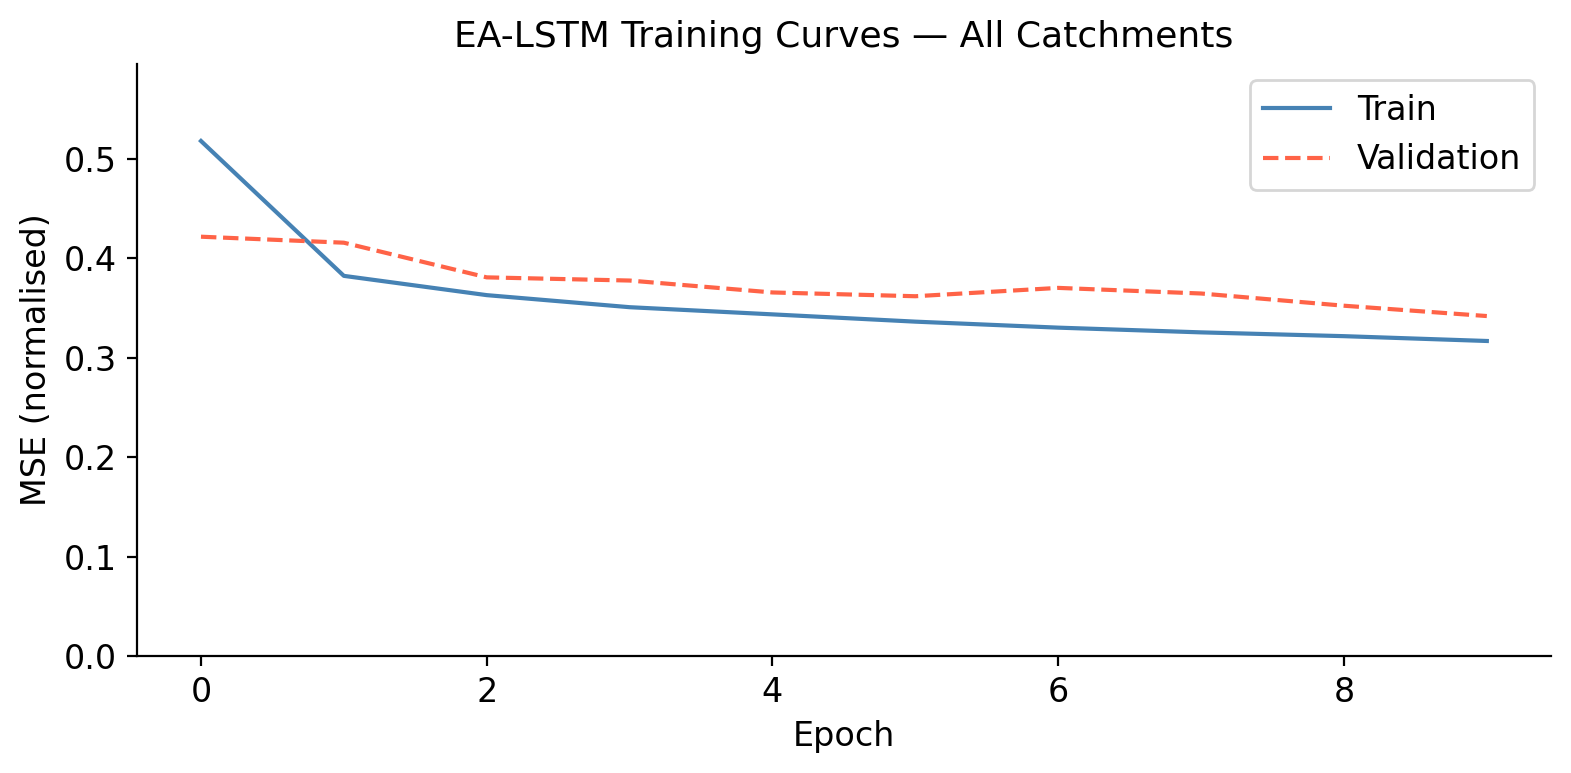

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, color='steelblue', lw=1.5, label='Train')
ax.plot(val_losses,   color='tomato',    lw=1.5, ls='--', label='Validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (normalised)')
ax.set_ylim(0, max(max(train_losses), max(val_losses)) * 1.15)
ax.legend()
ax.set_title('EA-LSTM Training Curves — All Catchments', fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 5 — Evaluate: Unseen Time & Unseen Catchments

We test generalisation on **two axes simultaneously**:

| Split | Catchments | Time period | What it tests |
|-------|-----------|-------------|---------------|
| **Seen / unseen time** | Training catchments | Test 2005–2008 | Temporal generalisation |
| **Unseen / unseen time** | Held-out catchments | Test 2005–2008 | Spatial generalisation |

If the model has learned a physical rainfall-runoff relationship rather than memorising each catchment, it should perform similarly on both. A large gap means the model is overfitting to the specific catchments it trained on.

In [26]:
EVAL_BATCH = 512

def evaluate_all(model, forcing_list, discharge_list, static_mat,
                 discharge_mu_list, discharge_std_list, mask, seq_len):
    """Returns NSE for each catchment on the given time mask."""
    model.eval()
    nse_scores = []
    for c in range(len(forcing_list)):
        if c % 100 == 0:
            print(f'  {c}/{len(forcing_list)} ...', end='\r')
        tidx = [t for t in range(seq_len - 1, len(discharge_list[c])) if mask[t]]
        if len(tidx) < 10:
            nse_scores.append(np.nan)
            continue
        F, q = forcing_list[c], discharge_list[c]
        mu, std = discharge_mu_list[c], discharge_std_list[c]
        s = static_mat[c]
        X_all = torch.from_numpy(np.stack([F[t - seq_len + 1 : t + 1] for t in tidx]))
        s_all = torch.from_numpy(np.tile(s, (len(tidx), 1)))
        preds = []
        with torch.no_grad():
            for start in range(0, len(tidx), EVAL_BATCH):
                xb = X_all[start:start+EVAL_BATCH].to(device)
                sb = s_all[start:start+EVAL_BATCH].to(device)
                preds.append(model(xb, sb).cpu())
        y_pred = np.maximum(np.exp(torch.cat(preds).numpy().flatten() * std + mu) - EPSILON, 0)
        y_obs  = np.maximum(np.exp(q[tidx] * std + mu) - EPSILON, 0)
        nse_scores.append(nse(y_obs, y_pred))
    return np.array(nse_scores)


def print_nse_summary(label, scores):
    v = scores[~np.isnan(scores)]
    print(f'\n{label} ({len(v)} catchments):')
    print(f'  Median : {np.median(v):.3f}   Mean : {np.mean(v):.3f}')
    print(f'  NSE > 0.7 : {(v > 0.7).mean()*100:.1f}%   NSE < 0 : {(v < 0).mean()*100:.1f}%')


print('── Seen catchments, unseen time (temporal generalisation) ──')
nse_seen = evaluate_all(model,
    forcing_all[train_cidx], discharge_all[train_cidx], static_norm[train_cidx],
    discharge_mu[train_cidx], discharge_std[train_cidx], test_mask, SEQ_LEN)
print_nse_summary('Seen catchments  / test period', nse_seen)

print('\n── Unseen catchments, unseen time (spatial generalisation) ──')
nse_unseen = evaluate_all(model,
    forcing_all[holdout_cidx], discharge_all[holdout_cidx], static_norm[holdout_cidx],
    discharge_mu[holdout_cidx], discharge_std[holdout_cidx], test_mask, SEQ_LEN)
print_nse_summary('Unseen catchments / test period', nse_unseen)

# Keep nse_test as all catchments combined (for map)
nse_test = np.concatenate([nse_seen, nse_unseen])

── Seen catchments, unseen time (temporal generalisation) ──
  500/534 ...
Seen catchments  / test period (534 catchments):
  Median : 0.431   Mean : -28.579
  NSE > 0.7 : 12.9%   NSE < 0 : 22.7%

── Unseen catchments, unseen time (spatial generalisation) ──
  100/134 ...
Unseen catchments / test period (134 catchments):
  Median : 0.290   Mean : -493.107
  NSE > 0.7 : 8.2%   NSE < 0 : 38.1%


In [27]:
v_seen   = nse_seen[~np.isnan(nse_seen)]
v_unseen = nse_unseen[~np.isnan(nse_unseen)]

print("NSE — Seen catchments    "
      f"median={np.median(v_seen):.3f}  min={v_seen.min():.3f}  max={v_seen.max():.3f}  (n={len(v_seen)})")
print("NSE — Unseen catchments  "
      f"median={np.median(v_unseen):.3f}  min={v_unseen.min():.3f}  max={v_unseen.max():.3f}  (n={len(v_unseen)})")

NSE — Seen catchments    median=0.431  min=-3547.601  max=0.906  (n=534)
NSE — Unseen catchments  median=0.290  min=-35418.038  max=0.842  (n=134)


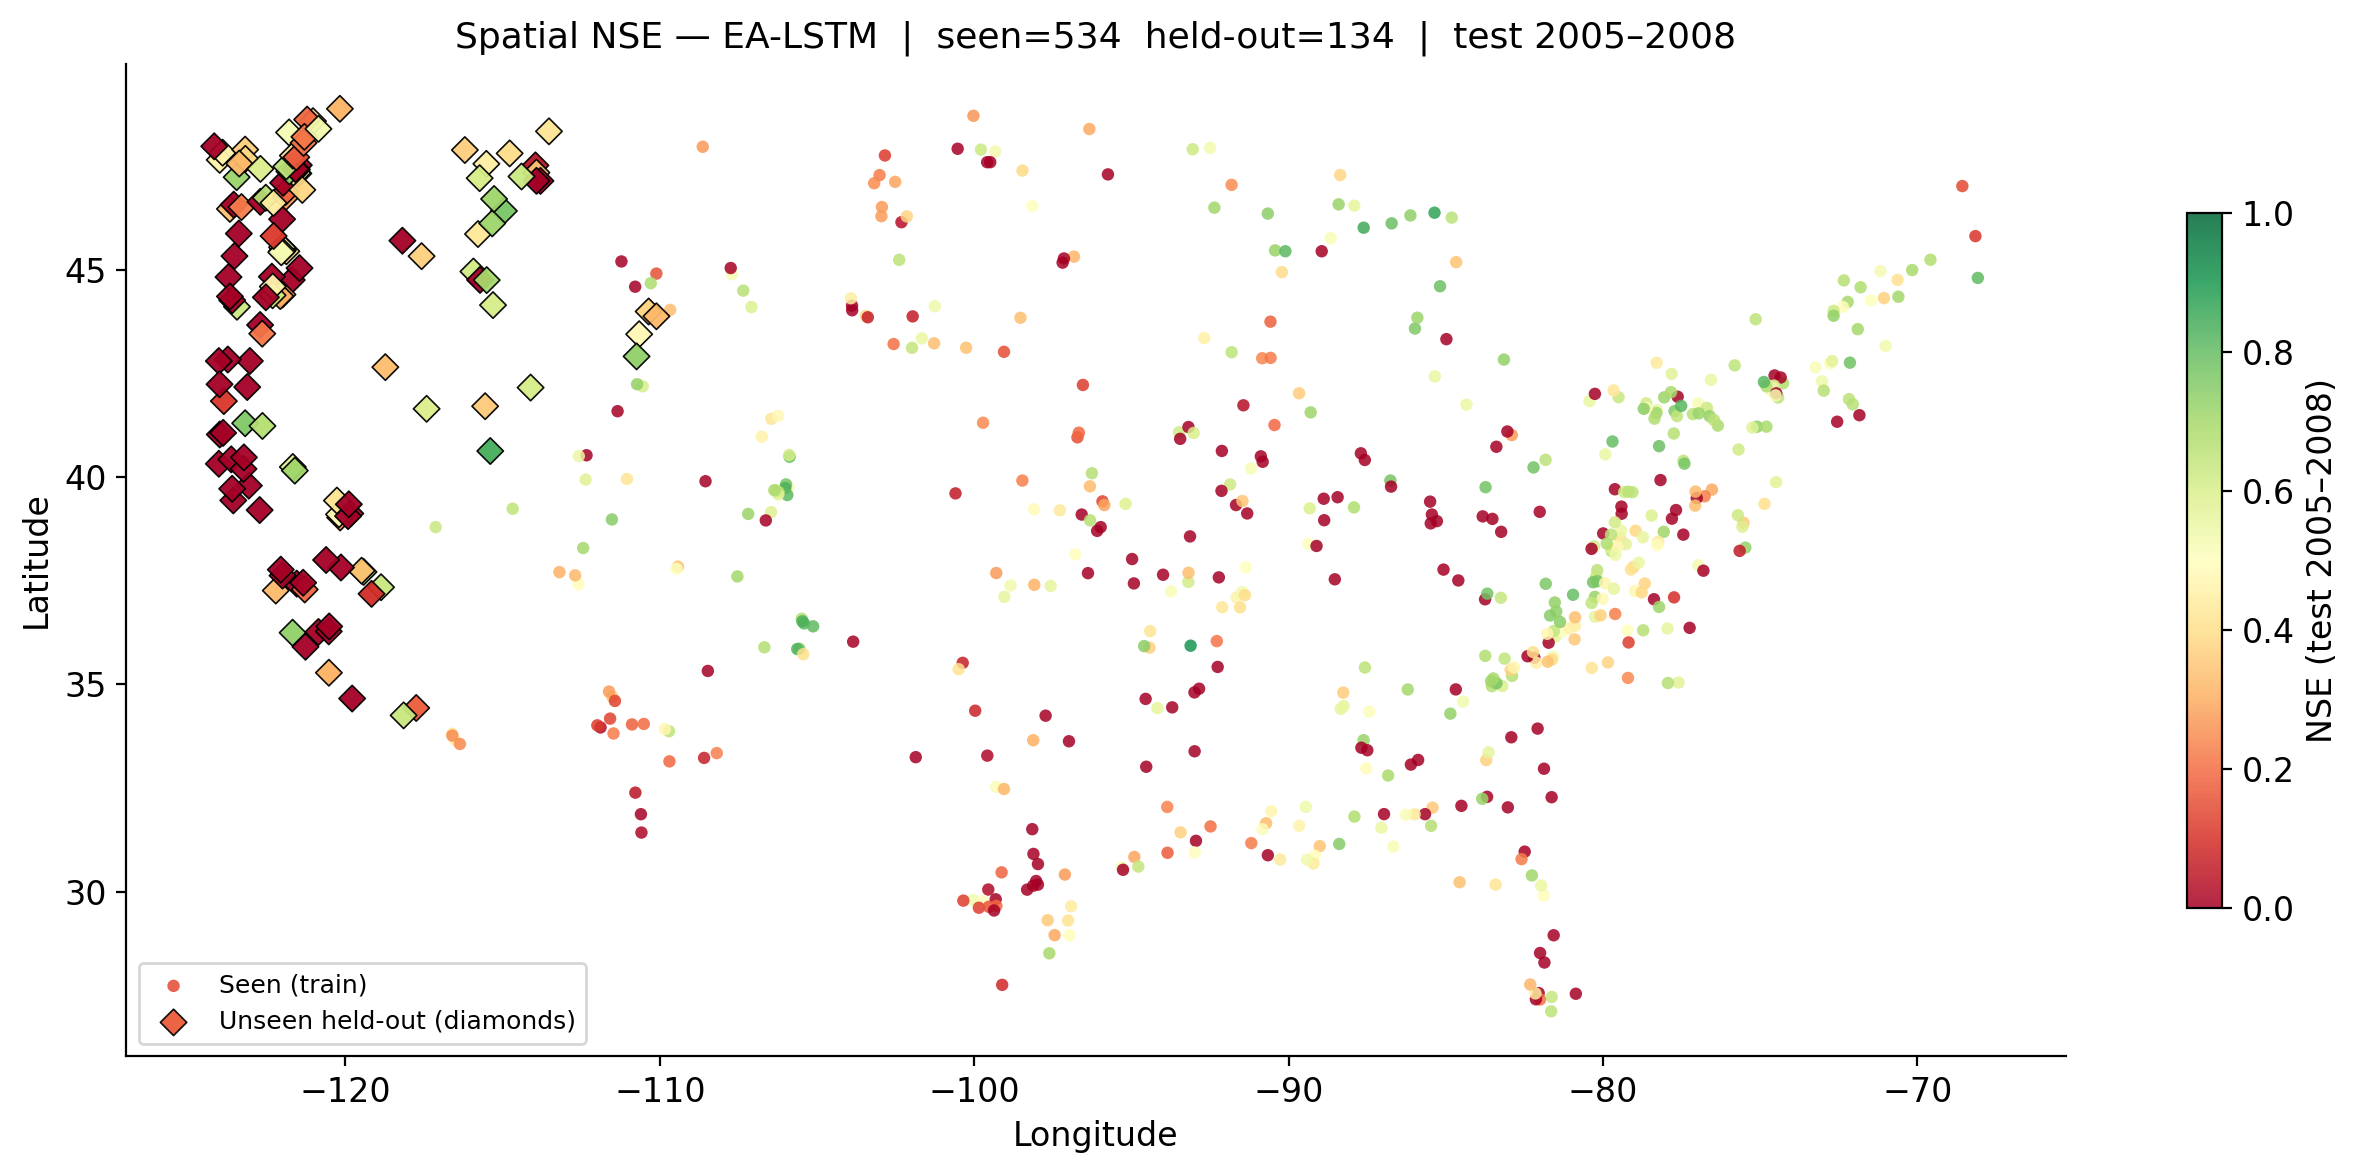

In [28]:
cent = camels.geometry.centroid

# Coordinates for all catchments (train + held-out, in the same order as valid_ids)
lx_seen   = cent.loc[train_ids].x.values
ly_seen   = cent.loc[train_ids].y.values
lx_unseen = cent.loc[held_out_ids].x.values
ly_unseen = cent.loc[held_out_ids].y.values

fig, ax = plt.subplots(figsize=(13, 6))

# Seen catchments — circles
sc1 = ax.scatter(lx_seen, ly_seen,
                 c=np.clip(nse_seen, -0.5, 1.0),
                 cmap='RdYlGn', vmin=0, vmax=1,
                 s=20, alpha=0.85, edgecolors='none',
                 marker='o', zorder=3, label='Seen (train)')

# Unseen catchments — diamonds, black edge to distinguish
sc2 = ax.scatter(lx_unseen, ly_unseen,
                 c=np.clip(nse_unseen, -0.5, 1.0),
                 cmap='RdYlGn', vmin=0, vmax=1,
                 s=45, alpha=0.95, edgecolors='black', linewidths=0.6,
                 marker='D', zorder=4, label='Unseen held-out (diamonds)')

plt.colorbar(sc1, ax=ax, label='NSE (test 2005–2008)', shrink=0.7)
ax.legend(fontsize=9, loc='lower left')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(
    f'Spatial NSE — EA-LSTM  |  seen={len(train_ids)}  held-out={len(held_out_ids)}  |  test 2005–2008',
    fontsize=13)
plt.tight_layout()
plt.show()

### Best and worst catchments

In [29]:
# Top 5 and bottom 5 by NSE
order = np.argsort(nse_test)
order = order[~np.isnan(nse_test[order])]

def label(i):
    gid = valid_ids[i]
    nm  = camels.loc[gid, name_col] if name_col else gid
    return f'{gid}  {nm[:30]}'

print('── Best 5 ──────────────────────────────────────────────────')
for i in order[-5:][::-1]:
    print(f'  NSE = {nse_test[i]:.3f}   {label(i)}')

print('\n── Worst 5 ─────────────────────────────────────────────────')
for i in order[:5]:
    print(f'  NSE = {nse_test[i]:.3f}   {label(i)}')

── Best 5 ──────────────────────────────────────────────────
  NSE = 0.906   07056000  Buffalo River Near St. Joe, AR
  NSE = 0.871   04045500  Tahquamenon River Near Paradis
  NSE = 0.850   04059500  Ford River Near Hyde, MI
  NSE = 0.842   10316500  Lamoille C Nr Lamoille, NV
  NSE = 0.832   08271000  Rio Lucero Near Arroyo Seco, N

── Worst 5 ─────────────────────────────────────────────────
  NSE = -35418.038   12144000  Sf Snoqualmie River At North B
  NSE = -8975.343   12095000  South Prairie Creek At South P
  NSE = -5109.109   12143600  Sf Snoqualmie River At Edgewic
  NSE = -4772.760   14303200  Tucca Creek Near Blaine, OR
  NSE = -3547.601   06408700  Rhoads Fork Near Rochford, SD


### Example hydrographs

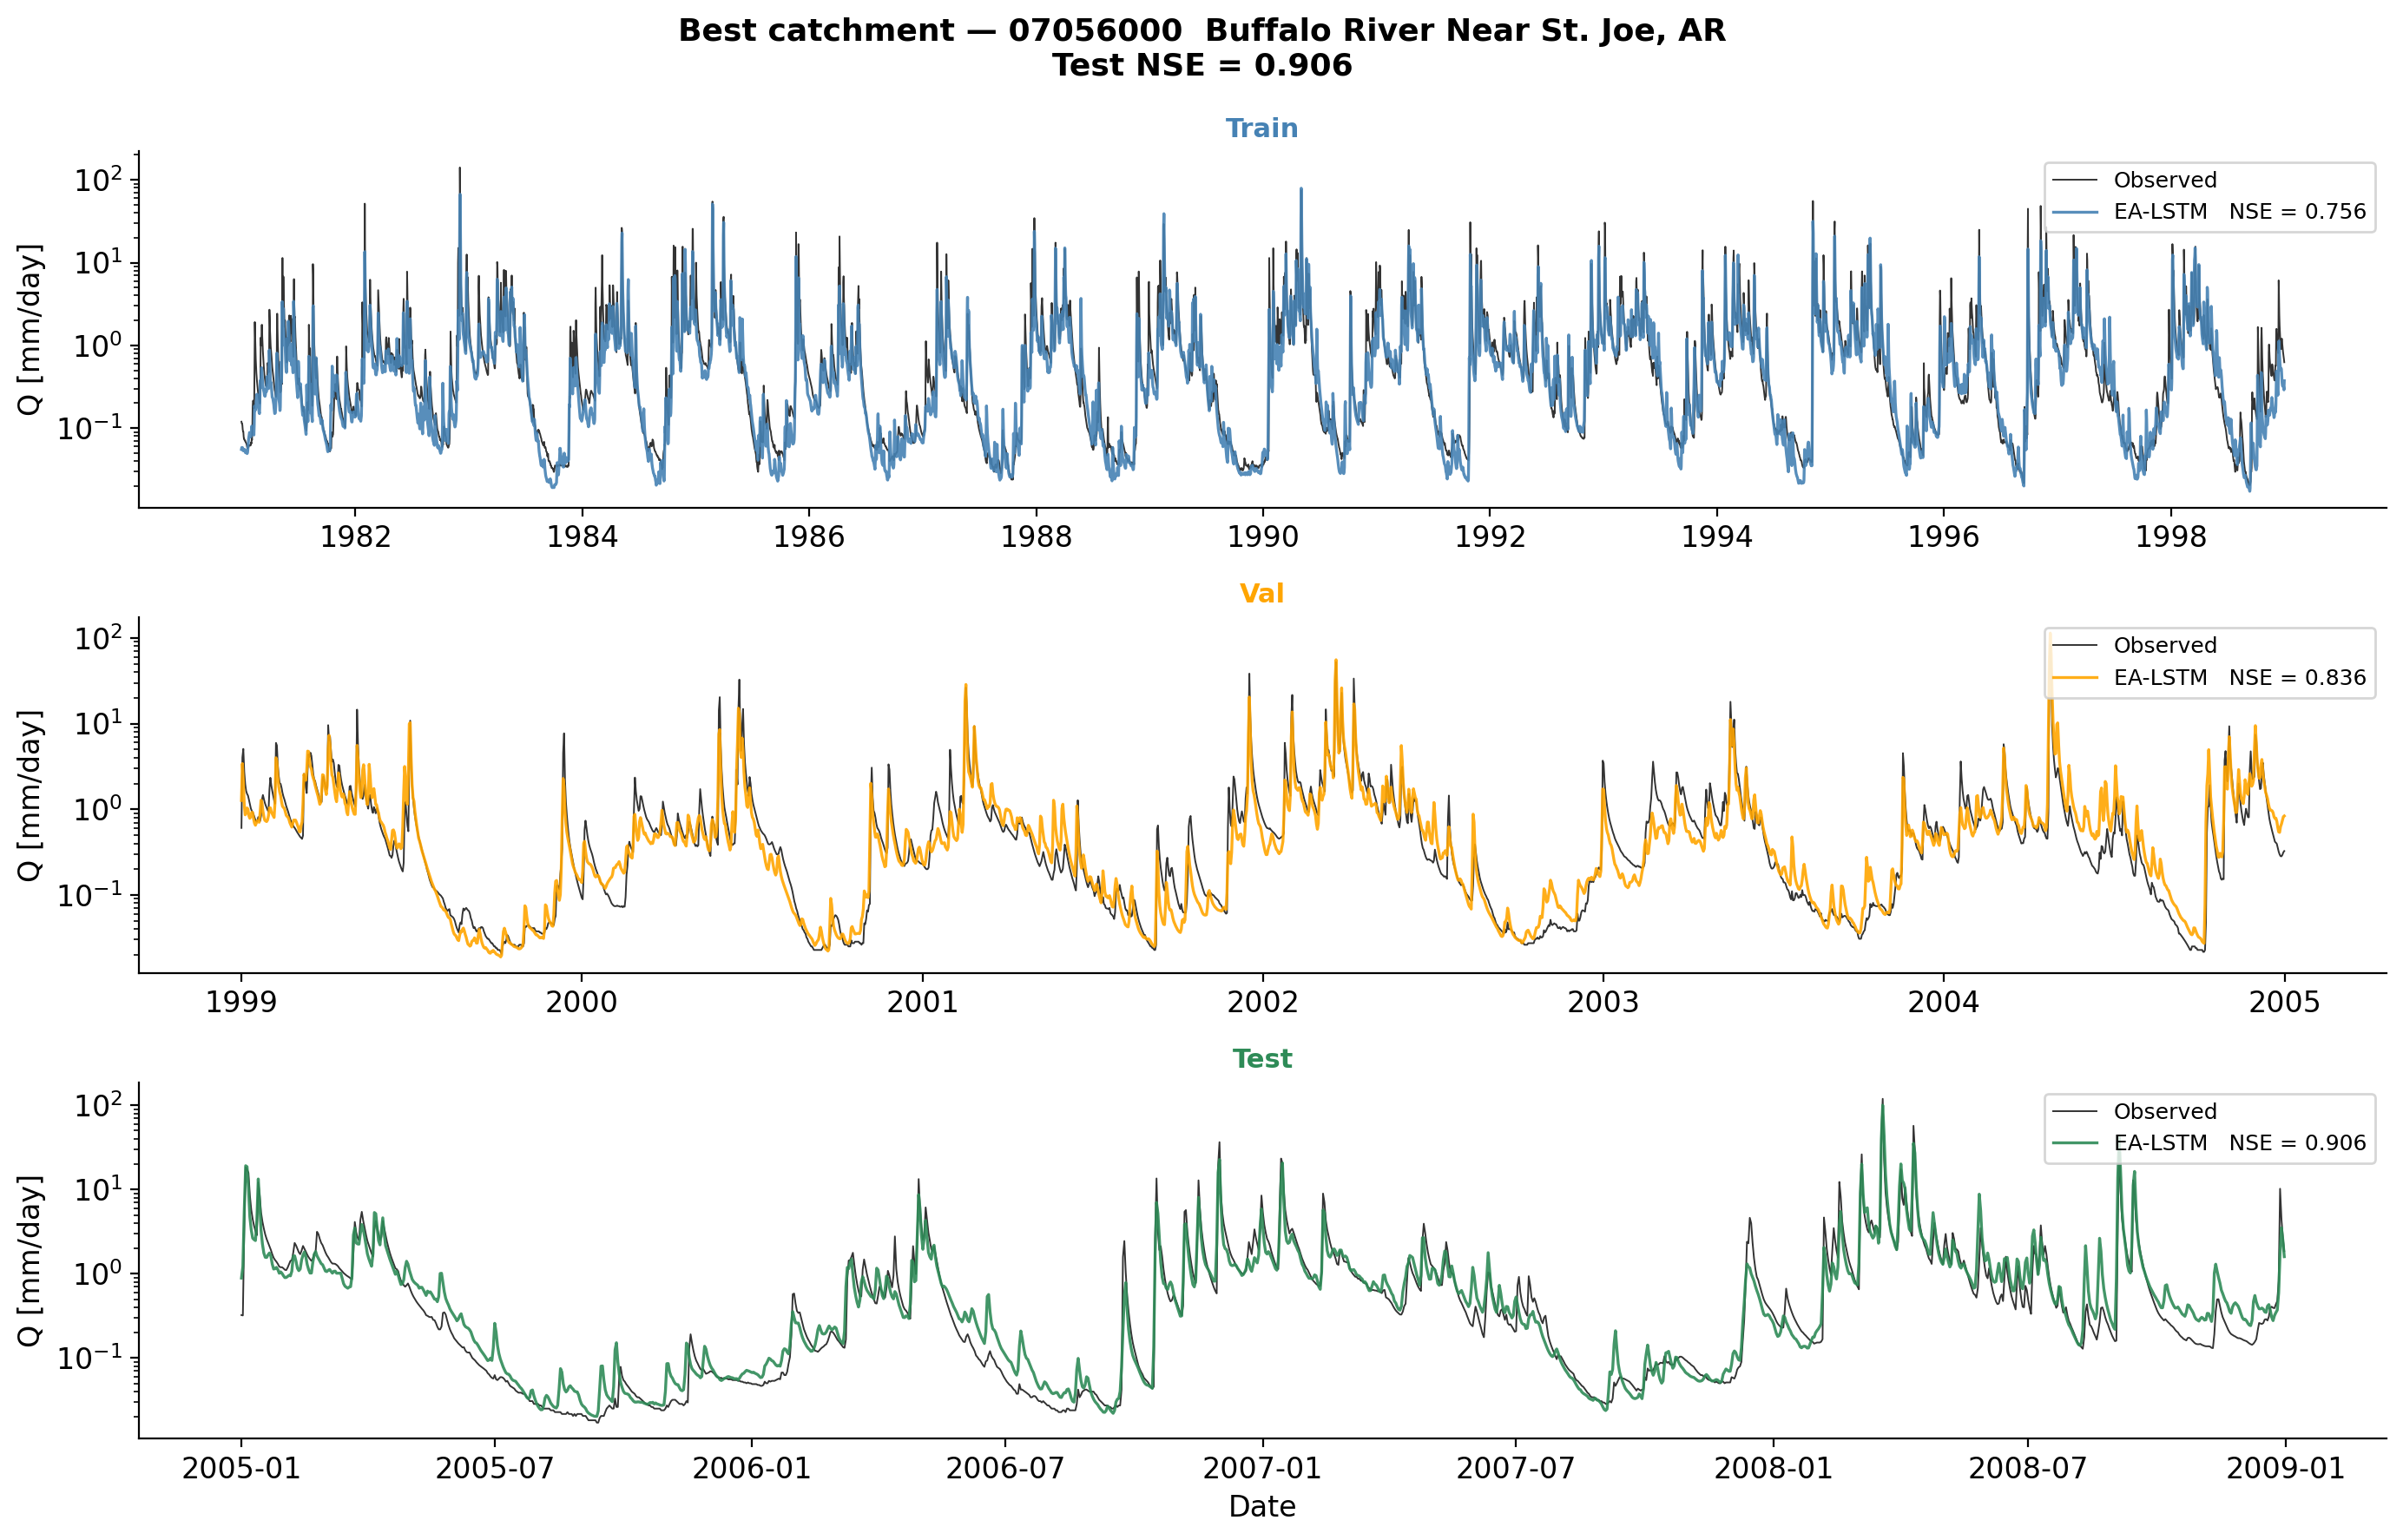

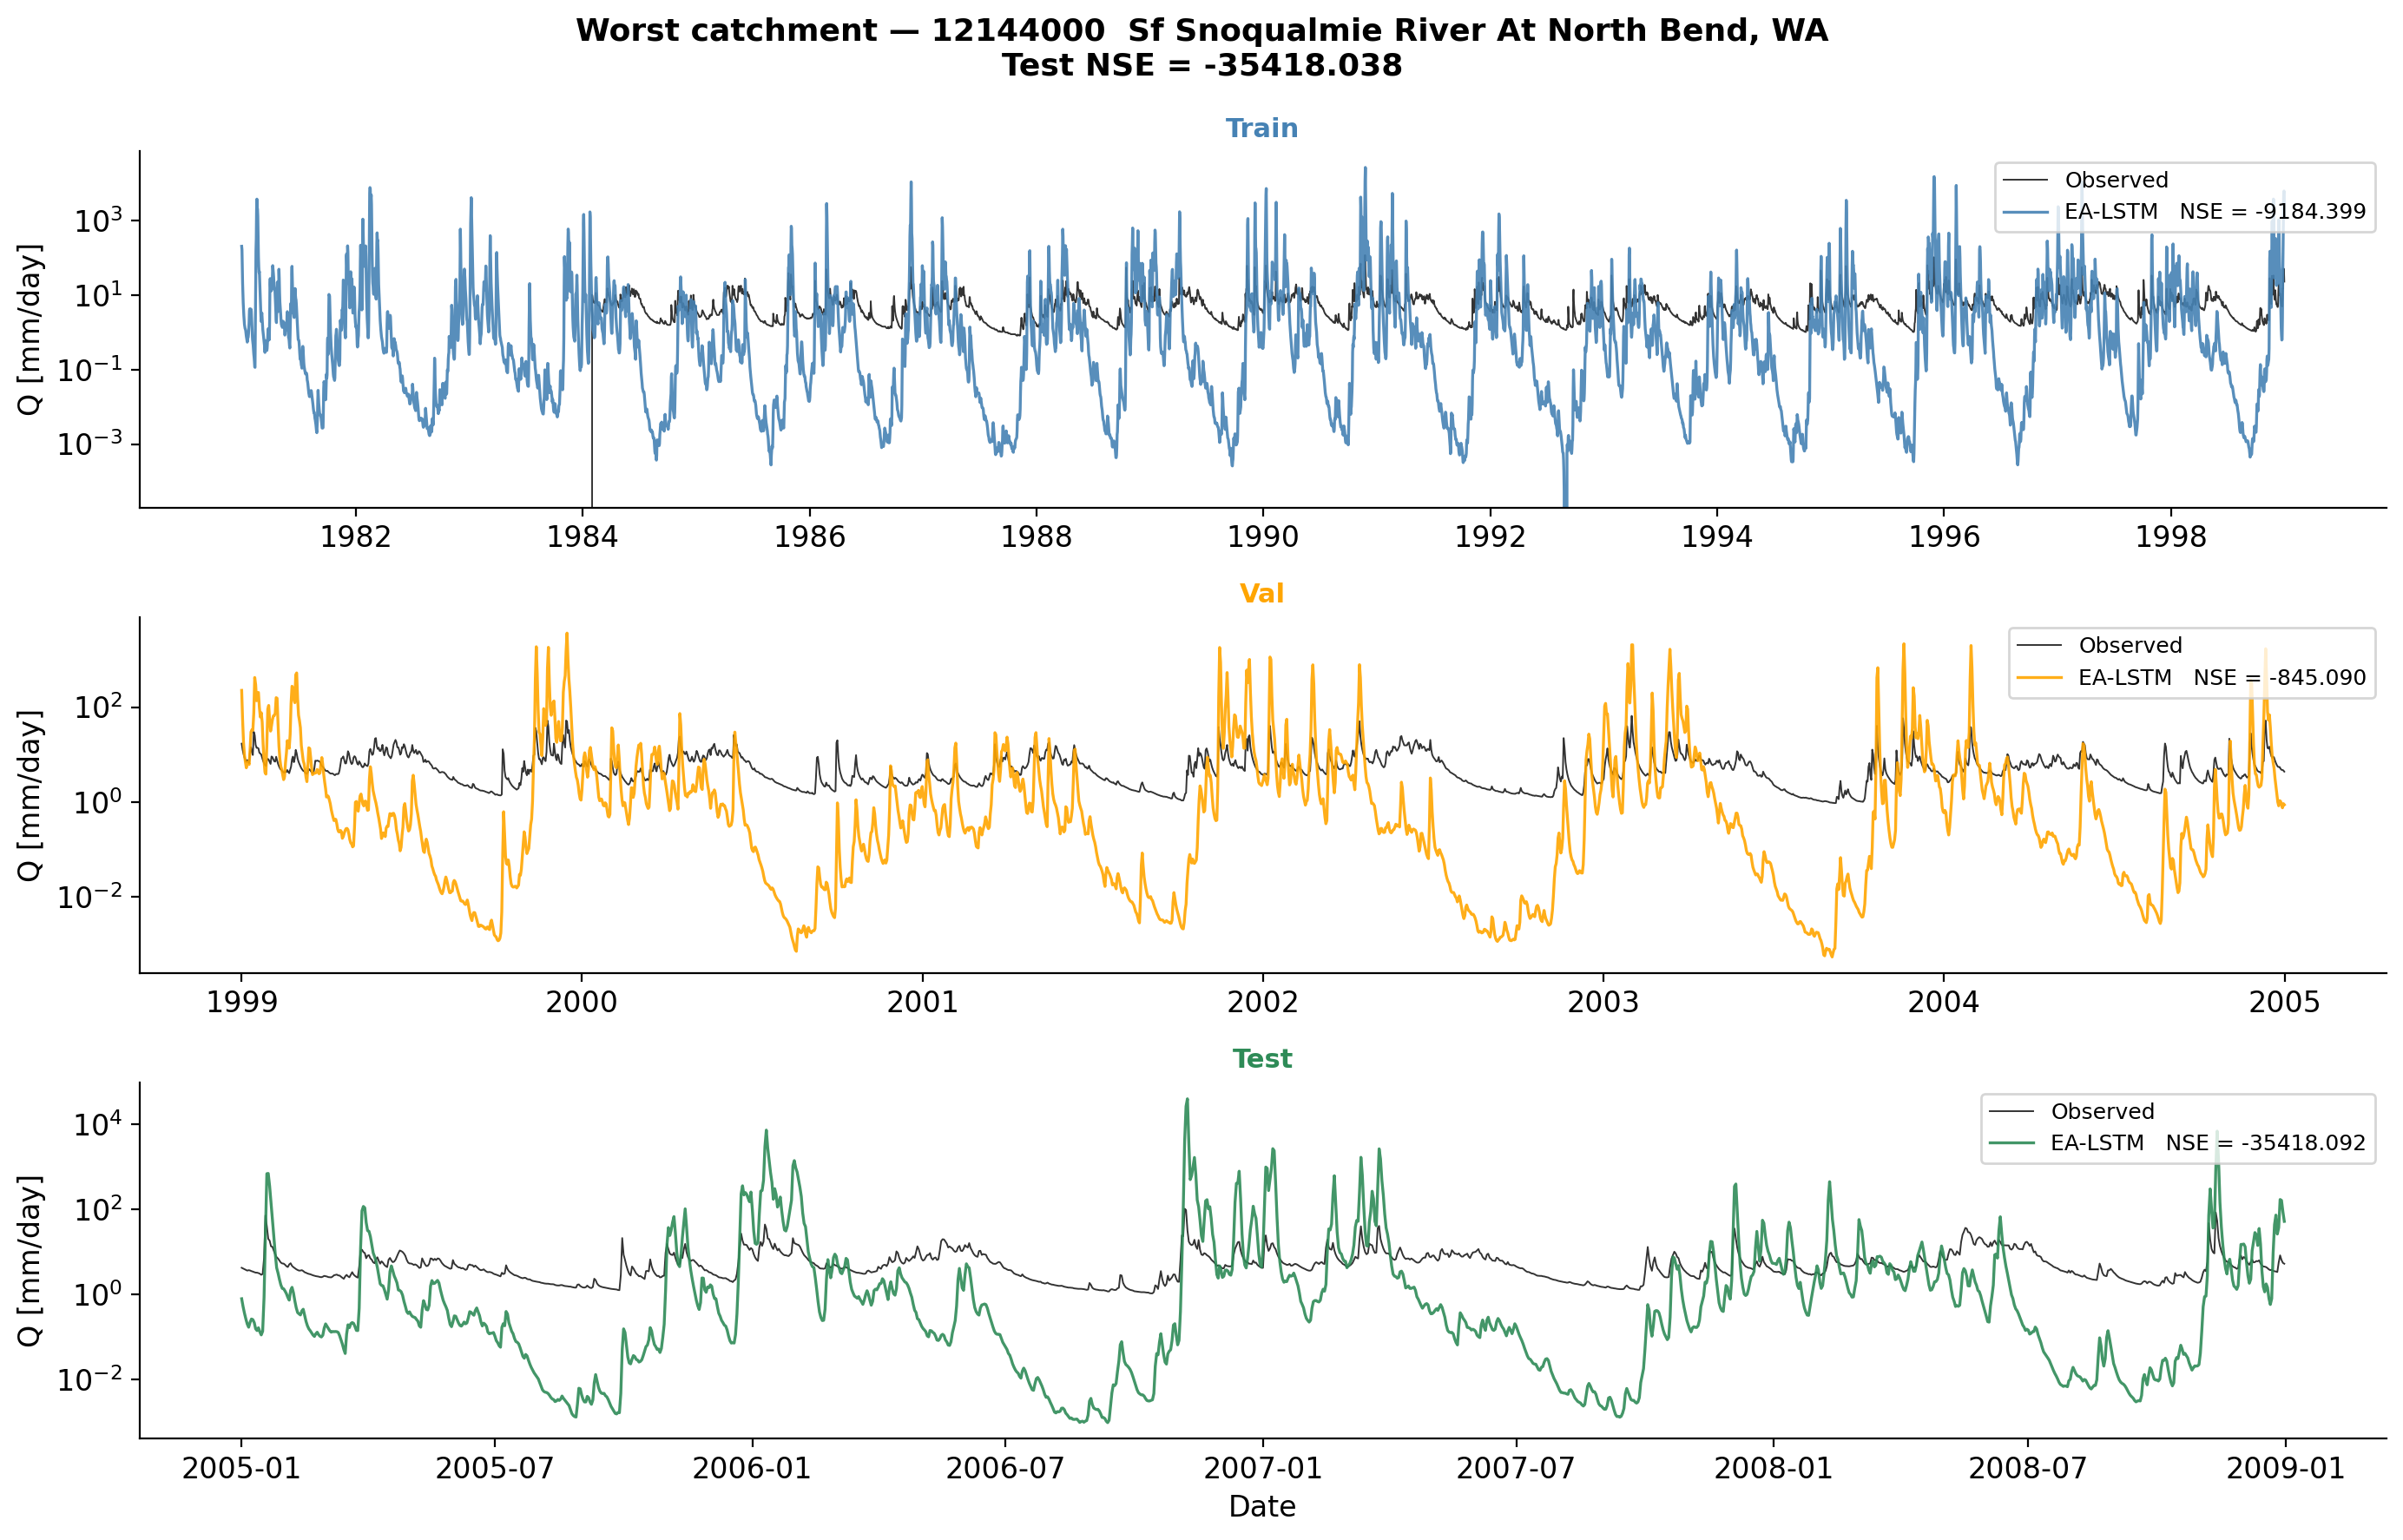

In [30]:
split_masks  = {'Train': train_mask, 'Val': val_mask, 'Test': test_mask}
split_colors = {'Train': 'steelblue', 'Val': 'orange', 'Test': 'seagreen'}

examples = [('Best', int(order[-1])), ('Worst', int(order[0]))]

for title_prefix, c in examples:
    gid = valid_ids[c]
    nm  = camels.loc[gid, name_col] if name_col else gid
    mu  = discharge_mu[c]
    std = discharge_std[c]
    F   = forcing_all[c]
    q   = discharge_all[c]
    s   = static_norm[c]

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
    fig.suptitle(f'{title_prefix} catchment — {gid}  {nm[:50]}\n'
                 f'Test NSE = {nse_test[c]:.3f}', fontsize=13, fontweight='bold')

    for ax, (split, mask) in zip(axes, split_masks.items()):
        tidx = [t for t in range(SEQ_LEN - 1, len(q)) if mask[t]]
        if not tidx:
            ax.set_visible(False)
            continue

        X_np = np.stack([F[t - SEQ_LEN + 1 : t + 1] for t in tidx])
        X_t  = torch.from_numpy(X_np).to(device)
        s_t  = torch.from_numpy(s).unsqueeze(0).expand(len(tidx), -1).to(device)

        model.eval()
        with torch.no_grad():
            y_pred_norm = model(X_t, s_t).cpu().numpy().flatten()

        y_pred = np.maximum(np.exp(y_pred_norm * std + mu) - EPSILON, 0)
        y_obs  = np.maximum(np.exp(q[tidx]     * std + mu) - EPSILON, 0)
        nse_s  = nse(y_obs, y_pred)
        t_plot = dates[tidx]

        ax.plot(t_plot, y_obs,  color='k',                   lw=0.7, alpha=0.8, label='Observed')
        ax.plot(t_plot, y_pred, color=split_colors[split],   lw=1.2, alpha=0.9,
                label=f'EA-LSTM   NSE = {nse_s:.3f}')
        ax.set_yscale('log')
        ax.set_ylabel('Q [mm/day]')
        ax.set_title(split, fontsize=11, color=split_colors[split], fontweight='bold')
        ax.legend(fontsize=9, loc='upper right')

    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

---
## Part 6 — SHAP Explanations

The EA-LSTM has **two separate inputs**, so SHAP returns two separate attribution arrays:

| Input | Shape | SHAP output |
|-------|-------|-------------|
| Forcing sequence | (batch, 365, 6) | (N, 365, 6) — importance per variable per day |
| Static attributes | (batch, 28) | (N, 28) — importance per catchment attribute |

We pass both as a list to `GradientExplainer`. It computes gradients w.r.t. each input independently via backpropagation, on the GPU if available.

### What the three plots show

| Plot | Question answered |
|------|-------------------|
| **Static feature importance** | Which of the 28 catchment attributes most shapes the model's predictions? |
| **Forcing feature importance** | Which of the 6 forcing variables matters most overall (averaged over time)? |
| **Memory depth** | How far back in the forcing sequence does the model look? |

In [31]:
import shap

np.random.seed(42)
BG_SIZE   = 50
N_EXPLAIN = 50

# Background: random sample from training set
bg_idx     = np.random.choice(len(train_ds), BG_SIZE, replace=False)
X_dyn_bg   = torch.stack([train_ds[i][0] for i in bg_idx]).to(device)
X_stat_bg  = torch.stack([train_ds[i][1] for i in bg_idx]).to(device)

# Explain: random sample from test set
test_ds    = MultiCatchmentDataset(forcing_all, discharge_all, static_norm, SEQ_LEN, test_mask)
te_idx     = np.random.choice(len(test_ds), N_EXPLAIN, replace=False)
X_dyn_te   = torch.stack([test_ds[i][0] for i in te_idx]).to(device)
X_stat_te  = torch.stack([test_ds[i][1] for i in te_idx]).to(device)

# GradientExplainer needs backprop; CuDNN RNN only supports backward in train mode.
# Switch to train() but disable Dropout so SHAP values are deterministic.
explainer  = shap.GradientExplainer(model, [X_dyn_bg, X_stat_bg])
# GradientExplainer calls model.eval() internally — override it before shap_values().
model.train()
for m in model.modules():
    if isinstance(m, torch.nn.Dropout):
        m.eval()
shap_raw   = explainer.shap_values([X_dyn_te, X_stat_te])
model.eval()

# Handle both list-of-lists and flat-list returns across SHAP versions
if isinstance(shap_raw[0], list):
    sv_dyn, sv_stat = shap_raw[0]
else:
    sv_dyn, sv_stat = shap_raw

sv_dyn  = np.squeeze(sv_dyn)   # (N, SEQ_LEN, 6)  or (N, 6, SEQ_LEN)
sv_stat = np.squeeze(sv_stat)  # (N, 28)

# Ensure sv_dyn is (N, SEQ_LEN, n_forcing)
if sv_dyn.ndim == 3 and sv_dyn.shape[1] == len(FORCING_VARS):
    sv_dyn = sv_dyn.transpose(0, 2, 1)

print(f"sv_dyn shape : {sv_dyn.shape}")
print(f"sv_stat shape: {sv_stat.shape}")

sv_dyn shape : (50, 365, 6)
sv_stat shape: (50, 28)


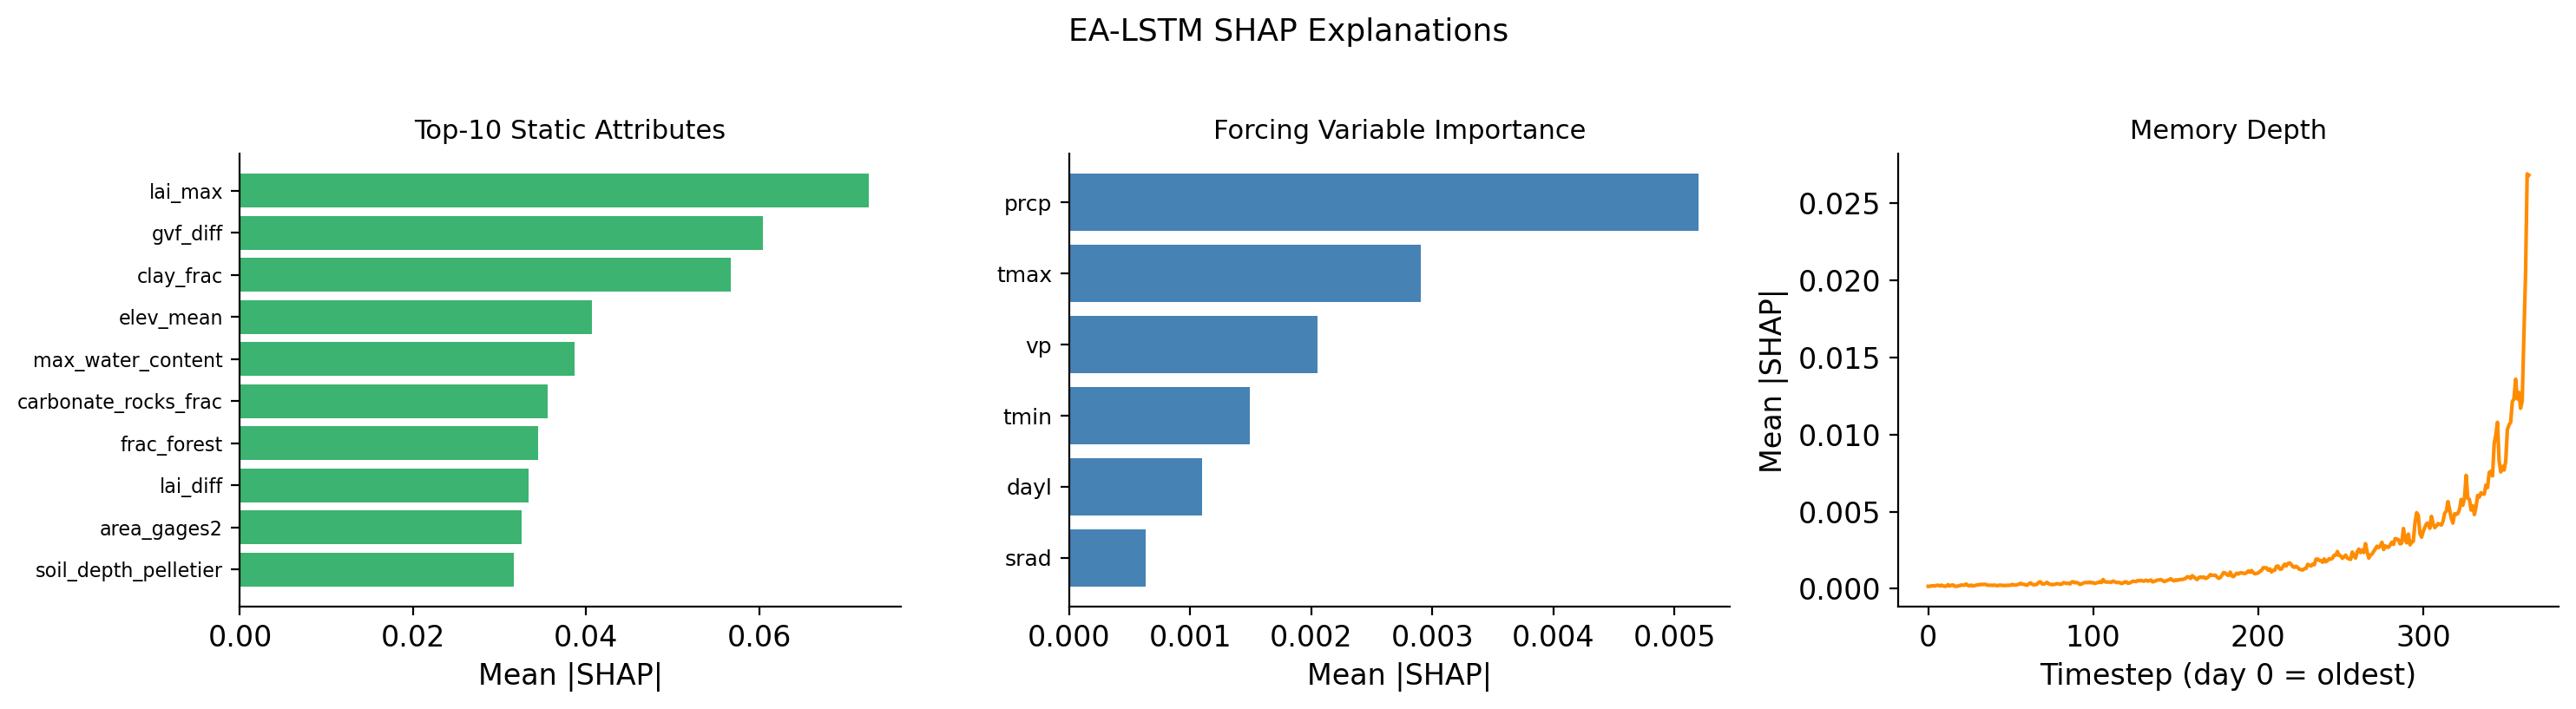

In [32]:
STATIC_ATTRS = [
    'elev_mean','slope_mean','area_gages2','frac_forest','lai_max','lai_diff',
    'gvf_max','gvf_diff','soil_depth_pelletier','soil_depth_statsgo',
    'soil_porosity','soil_conductivity','max_water_content','sand_frac',
    'silt_frac','clay_frac','water_frac','organic_frac','other_frac',
    'geol_1st_class','glim_1st_class_frac','geol_2nd_class','glim_2nd_class_frac',
    'carbonate_rocks_frac','geol_porostiy','geol_permeability',
    'p_mean','pet_mean'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Panel 1: Static attribute importance ──────────────────────────────────
mean_stat = np.abs(sv_stat).mean(axis=0)          # (28,)
order_stat = np.argsort(mean_stat)[::-1]
top_n = 10
ax = axes[0]
ax.barh(range(top_n), mean_stat[order_stat[:top_n]][::-1], color='mediumseagreen')
ax.set_yticks(range(top_n))
ax.set_yticklabels([STATIC_ATTRS[int(i)] for i in order_stat[:top_n]][::-1], fontsize=8)
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Top-10 Static Attributes', fontsize=11)

# ── Panel 2: Forcing variable importance ─────────────────────────────────
mean_dyn = np.abs(sv_dyn).mean(axis=(0, 1))       # (6,)
order_dyn = np.argsort(mean_dyn)[::-1]
ax = axes[1]
ax.barh(range(len(FORCING_VARS)), mean_dyn[order_dyn][::-1], color='steelblue')
ax.set_yticks(range(len(FORCING_VARS)))
ax.set_yticklabels([FORCING_VARS[int(i)] for i in order_dyn][::-1], fontsize=9)
ax.set_xlabel('Mean |SHAP|')
ax.set_title('Forcing Variable Importance', fontsize=11)

# ── Panel 3: Memory depth — SHAP magnitude over lag ──────────────────────
mean_over_time = np.abs(sv_dyn).mean(axis=(0, 2))  # (SEQ_LEN,)
lags = np.arange(SEQ_LEN)
ax = axes[2]
ax.plot(lags, mean_over_time, color='darkorange', lw=1.5)
ax.set_xlabel('Timestep (day 0 = oldest)')
ax.set_ylabel('Mean |SHAP|')
ax.set_title('Memory Depth', fontsize=11)

plt.suptitle('EA-LSTM SHAP Explanations', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

### What changed from Notebook 02 → 03?

| | 02 — Dynamic only | 03 — Full EA-LSTM |
|---|---|---|
| **Input** | 6 forcing vars × 365 days | 6 forcing + 28 static attributes |
| **Model** | Per-catchment standard LSTM | One shared EA-LSTM for all catchments |
| **Static role** | None | Conditions input gate at **every** timestep |
| **Custom cell** | No (uses `nn.LSTM`) | Yes (`EALSTMCell` with $V_i \cdot \mathbf{s}$) |
| **Training data** | ~6,500 sequences | ~4.4 M sequences (all catchments) |
| **Generalisation** | Memorises one site | Learns across climate space |


### References

- Kratzert, F., Klotz, D., Brenner, C., Schulz, K., & Herrnegger, M. (2019). Towards learning universal, regional, and local hydrological behaviors via machine learning applied to large-domain datasets. *Hydrology and Earth System Sciences*, 23(12), 5089–5110.
- Newman, A., et al. (2015). Development of a large-sample watershed-scale hydrometeorological dataset for the contiguous USA. *HESS*, 19, 209–223.  
  Dataset: https://www.hydroshare.org/resource/17c896843cf940339c3c3496d0c1c077/